In [2]:
import duckdb
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

### Paso 1: Carga de los datos y división de los datos en muestra de entreno y test

In [3]:
con = duckdb.connect()

In [4]:
train_sample = con.execute("""

SELECT *

FROM read_parquet(
    '../data/modeling/features_v2.parquet'
)

WHERE fecha_hora < '2026-05-01'

USING SAMPLE 10% (bernoulli, 42)

""").pl()

In [5]:
print(train_sample.shape)

(3274019, 49)


In [6]:
test_sample = con.execute("""

SELECT *

FROM read_parquet(
    '../data/modeling/features_v2.parquet'
)

WHERE fecha_hora >= '2026-05-01'

USING SAMPLE 15% (bernoulli, 42)

""").pl()

In [7]:
print(test_sample.shape)

(1024542, 49)


Tras comparar el rendimiento del modelo con distintos porcentajes de datos de entrenamiento, se observó que aumentar el tamaño de la muestra apenas producía mejoras en las métricas de evaluación. Esto indica que el modelo ya ha aprendido los patrones principales presentes en los datos y que incorporar un mayor volumen de registros supone un incremento del coste computacional sin una mejora significativa en la capacidad predictiva. Además, la diferencia entre las métricas obtenidas en entrenamiento y prueba se mantuvo reducida, lo que refleja una buena capacidad de generalización y la ausencia de indicios relevantes de sobreajuste. Por ello, se decidió mantener el porcentaje de muestreo inicial, ya que ofrece un equilibrio adecuado entre rendimiento predictivo y eficiencia computacional. A partir de este punto, las posibles mejoras del modelo pasan principalmente por el ajuste de hiperparámetros y la optimización del proceso de ingeniería de variables, más que por incrementar el volumen de datos de entrenamiento.

Se trabaja sobre `features_v2.parquet` (targets inválidos por saltos temporales filtrados) y con muestreo determinístico (`bernoulli, 42`) para garantizar la reproducibilidad de las comparaciones entre modelos.

### Paso 2: Separación de variables en featrures y target

In [8]:
X_train = train_sample.drop([
    "target",
    "fecha_hora"
])

y_train = train_sample["target"]


X_test = test_sample.drop([
    "target",
    "fecha_hora"
])

y_test = test_sample["target"]

In [9]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3274019, 47)
y_train: (3274019,)
X_test: (1024542, 47)
y_test: (1024542,)


In [10]:
X_train.schema

Schema([('id_sensor', Int32),
        ('hora', Int32),
        ('intensidad_media', Float64),
        ('intensidad_max', Float64),
        ('intensidad_min', Float64),
        ('ocupacion_media', Float64),
        ('ocupacion_max', Float64),
        ('velocidad_media', Float64),
        ('velocidad_min', Float64),
        ('num_mediciones', Int64),
        ('num_error_E', Float64),
        ('porcentaje_calidad', Float64),
        ('año', Int64),
        ('mes', Int64),
        ('trimestre', Int64),
        ('dia', Int64),
        ('dia_semana', Int64),
        ('fin_semana', Boolean),
        ('tipo_elem', String),
        ('distrito', Int32),
        ('latitud', Float64),
        ('longitud', Float64),
        ('hora_sin', Float64),
        ('hora_cos', Float64),
        ('dia_semana_sin', Float64),
        ('dia_semana_cos', Float64),
        ('mes_sin', Float64),
        ('mes_cos', Float64),
        ('intensidad_media_lag_1', Float64),
        ('intensidad_media_lag_24', Float64),


#### Conversión de la columna `tipo_elem` a tipo Categorical

In [11]:
X_train = X_train.with_columns(
    pl.col("tipo_elem").cast(pl.Categorical)
)

X_test = X_test.with_columns(
    pl.col("tipo_elem").cast(pl.Categorical)
)

#### Conversión de las columnas de tipo Float64 y Int64 a 32 bits (Reducción de memoria y aligera el procesamiento)

In [12]:
X_train = X_train.with_columns(
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32)
)

X_test = X_test.with_columns(
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32)
)

In [13]:
X_train = X_train.with_columns(
    pl.col("fin_semana").cast(pl.Int8)
)

X_test = X_test.with_columns(
    pl.col("fin_semana").cast(pl.Int8)
)

#### Conversión de los dataframe de Polars a Pandas

In [14]:
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

In [15]:
X_train_pd["tipo_elem"] = X_train_pd["tipo_elem"].astype("category")
X_test_pd["tipo_elem"] = X_test_pd["tipo_elem"].astype("category")

In [16]:
categorical_features = [
    X_train_pd.columns.get_loc("tipo_elem")
]

### Paso 3: Baseline de persistencia

El target es `ocupacion_media` en t+1, por lo que la predicción trivial (persistencia) consiste en usar la ocupación **actual** (t) como estimación de la hora siguiente. Este baseline no requiere entrenamiento y establece el piso de rendimiento: todo modelo debe superarlo para justificar su complejidad.

In [17]:
y_true = y_test.to_numpy()

# Persistencia: ocupación actual (t) → predicción de t+1
pred_persist = test_sample["ocupacion_media"].to_numpy()

mae_persist = mean_absolute_error(y_true, pred_persist)
rmse_persist = root_mean_squared_error(y_true, pred_persist)
r2_persist = r2_score(y_true, pred_persist)

print("BASELINE persistencia (ocupacion_media en t)")
print(f"  MAE : {mae_persist:.4f}")
print(f"  RMSE: {rmse_persist:.4f}")
print(f"  R²  : {r2_persist:.4f}")

BASELINE persistencia (ocupacion_media en t)
  MAE : 2.0390
  RMSE: 4.4930
  R²  : 0.7960


In [18]:
# Partición interna de validación para el early stopping de LightGBM
# (HistGradientBoosting gestiona su validación internamente con validation_fraction)
corte_val = train_sample["fecha_hora"].quantile(0.9)

mask_tr = train_sample["fecha_hora"] < corte_val
mask_val = train_sample["fecha_hora"] >= corte_val

X_tr = X_train_pd[mask_tr.to_numpy()]
X_val = X_train_pd[mask_val.to_numpy()]
y_tr = y_train.to_numpy()[mask_tr.to_numpy()]
y_val = y_train.to_numpy()[mask_val.to_numpy()]

modelos = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=3000,
        learning_rate=0.1,
        max_leaf_nodes=63,
        categorical_features=categorical_features,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.1,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [19]:
resultados = []
modelos_entrenados = {}
predicciones = {}


for nombre, modelo in modelos.items():

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    # Entrenamiento (early stopping en ambos modelos)
    if nombre == "LightGBM":
        modelo.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(stopping_rounds=20),
                lgb.log_evaluation(0)
            ]
        )
        print(f"Iteraciones efectivas: {modelo.best_iteration_}")
    else:
        modelo.fit(
            X_train_pd,
            y_train.to_numpy()
        )
        print(f"Iteraciones efectivas: {modelo.n_iter_}")

    # Guardar modelo entrenado
    modelos_entrenados[nombre] = modelo

    # Predicciones
    pred_train = modelo.predict(X_train_pd)
    pred_test = modelo.predict(X_test_pd)

    # Guardar predicciones
    predicciones[nombre] = {
        "train": pred_train,
        "test": pred_test
    }


    # Métricas entrenamiento
    mae_train = mean_absolute_error(y_train, pred_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)
    r2_train = r2_score(y_train, pred_train)

    # Métricas prueba
    mae_test = mean_absolute_error(y_test, pred_test)
    rmse_test = root_mean_squared_error(y_test, pred_test)
    r2_test = r2_score(y_test, pred_test)


    print("\nEntrenamiento")
    print(f"MAE : {mae_train:.4f}")
    print(f"RMSE: {rmse_train:.4f}")
    print(f"R²  : {r2_train:.4f}")


    print("\nPrueba")
    print(f"MAE : {mae_test:.4f}")
    print(f"RMSE: {rmse_test:.4f}")
    print(f"R²  : {r2_test:.4f}")


    print("\nDiferencias")
    print(f"Δ MAE : {mae_test - mae_train:.4f}")
    print(f"Δ RMSE: {rmse_test - rmse_train:.4f}")
    print(f"Δ R²  : {r2_train - r2_test:.4f}")


    if (r2_train - r2_test) < 0.05:
        print("\nSin indicios de overfitting.")
    else:
        print("\nPosible overfitting.")


    resultados.append({
        "Modelo": nombre,
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R²": r2_test
    })


# Comparativa final
comparativa_modelos = (
    pd.DataFrame(resultados)
    .sort_values(
        by="R²",
        ascending=False
    )
)

comparativa_modelos

# Añadir el baseline de persistencia a la comparativa
resultados.append({
    "Modelo": "Baseline persistencia",
    "MAE": mae_persist,
    "RMSE": rmse_persist,
    "R²": r2_persist
})


HistGradientBoosting
Iteraciones efectivas: 1896

Entrenamiento
MAE : 1.1318
RMSE: 2.3848
R²  : 0.9320

Prueba
MAE : 1.4637
RMSE: 3.2804
R²  : 0.8913

Diferencias
Δ MAE : 0.3320
Δ RMSE: 0.8955
Δ R²  : 0.0407

Sin indicios de overfitting.
LightGBM
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1081]	valid_0's l1: 1.43168	valid_0's l2: 10.7922
Iteraciones efectivas: 1081

Entrenamiento
MAE : 1.1877
RMSE: 2.5534
R²  : 0.9220

Prueba
MAE : 1.4785
RMSE: 3.3273
R²  : 0.8881

Diferencias
Δ MAE : 0.2908
Δ RMSE: 0.7739
Δ R²  : 0.0339

Sin indicios de overfitting.


Tras comparar HistGradientBoostingRegressor y LightGBM — ambos con early stopping y capacidad ampliada (63 hojas, hasta 3000 iteraciones) — se seleccionó como modelo final el de mejor rendimiento en el conjunto de prueba. Ambos superan ampliamente el baseline de persistencia, lo que confirma que el modelo aporta valor real sobre la alternativa trivial de asumir que la ocupación de la próxima hora será igual a la actual.

*Nota: revisar esta interpretación y el nombre del modelo seleccionado en la celda siguiente tras ejecutar la comparativa sobre `features_v2.parquet`.*

In [20]:
# Selección automática del mejor modelo (menor MAE en test, excluyendo el baseline)
mejor = (
    pd.DataFrame(resultados)
    .query("Modelo != 'Baseline persistencia'")
    .sort_values("MAE")
    .iloc[0]["Modelo"]
)

print(f"Modelo seleccionado: {mejor}")

modelo_final = modelos_entrenados[mejor]

Modelo seleccionado: HistGradientBoosting


In [21]:
pred_test = predicciones[mejor]["test"]
pred_train = predicciones[mejor]["train"]

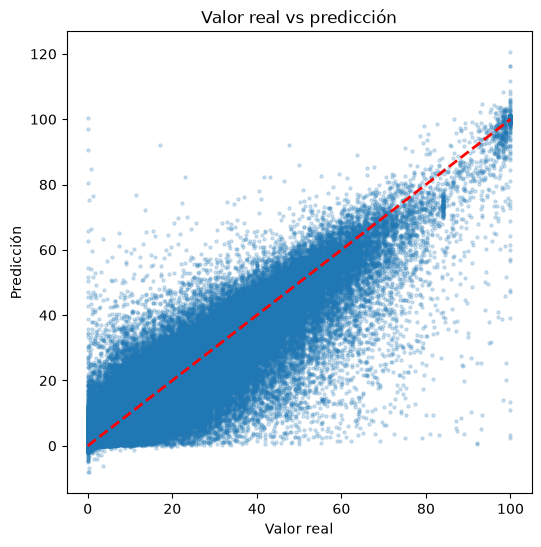

In [22]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test.to_numpy(),
    pred_test,
    alpha=0.2,
    s=5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Valor real vs predicción")

plt.show()

La nube de puntos se concentra mayoritariamente alrededor de la diagonal, lo que indica que las predicciones del modelo son, en general, muy próximas a los valores reales. Esta concentración refleja una buena capacidad predictiva y una alta correlación entre los valores observados y los estimados. A medida que aumentan los valores de ocupación, la dispersión de los puntos es ligeramente mayor y el número de observaciones disminuye, lo que es esperable debido a que existen menos casos con ocupaciones muy elevadas.

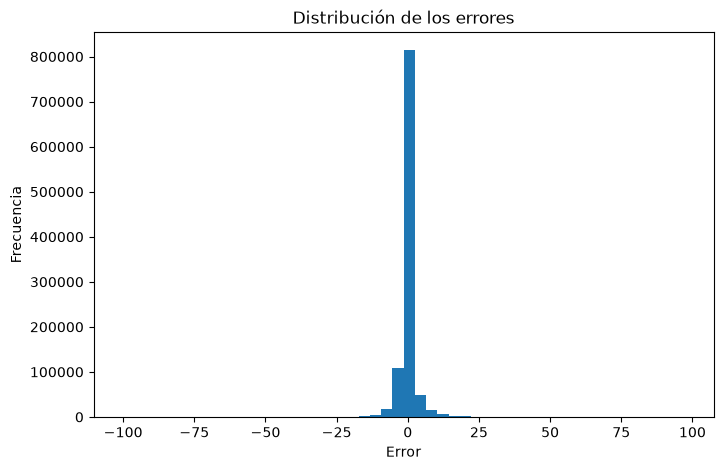

In [23]:
errores = y_test.to_numpy() - pred_test

plt.figure(figsize=(8,5))

plt.hist(
    errores,
    bins=50
)

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de los errores")

plt.show()

La distribución de los residuos se encuentra fuertemente concentrada en torno al valor cero, lo que indica que la mayoría de las predicciones presentan errores reducidos. Conforme aumenta la magnitud del error, la frecuencia disminuye de forma notable, observándose únicamente un número reducido de predicciones con errores elevados. Este comportamiento sugiere que el modelo realiza estimaciones precisas en la mayor parte de las observaciones y que los errores significativos se producen únicamente en casos puntuales.

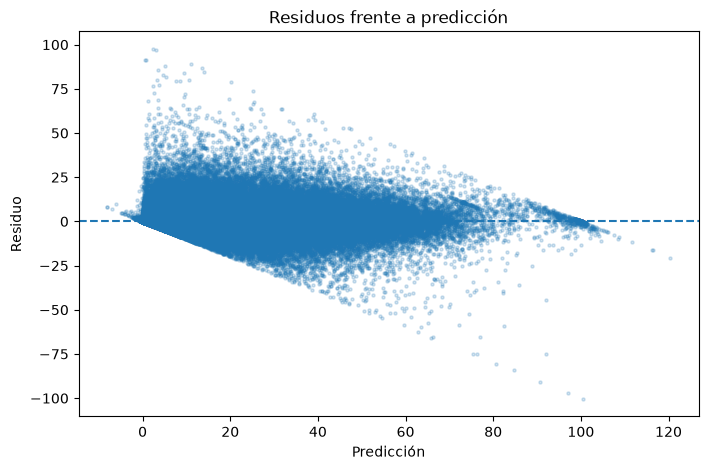

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    pred_test,
    errores,
    alpha=0.2,
    s=5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos frente a predicción")

plt.show()

El gráfico de residuos frente a las predicciones muestra que los errores se distribuyen de forma aproximadamente uniforme alrededor del valor cero, sin apreciarse patrones sistemáticos ni tendencias que indiquen un sesgo del modelo. La mayor concentración de residuos se encuentra próxima a cero, lo que confirma que la mayoría de las predicciones presentan errores reducidos. La ligera inclinación observada en la nube de puntos responde al rango limitado de la variable objetivo y no evidencia un comportamiento anómalo del modelo.

In [25]:
# Buscar un sensor con muchos valores distintos
sensor = (
    test_sample
    .group_by("id_sensor")
    .agg(pl.col("target").n_unique().alias("valores_distintos"))
    .sort("valores_distintos", descending=True)
)["id_sensor"][0]

print(f"Sensor seleccionado: {sensor}")

Sensor seleccionado: 6129


In [26]:
sensor_df = con.execute(f"""
SELECT *
FROM read_parquet('../data/modeling/features_v2.parquet')
WHERE id_sensor = {sensor}
  AND fecha_hora >= '2026-05-01'
ORDER BY fecha_hora
LIMIT 72
""").pl()

In [27]:
X_sensor = (
    sensor_df
    .drop(["target", "fecha_hora"])
    .with_columns(
        pl.col("tipo_elem").cast(pl.Categorical),
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32),
        pl.col("fin_semana").cast(pl.Int8)
    )
)

X_sensor_pd = X_sensor.to_pandas()
X_sensor_pd["tipo_elem"] = X_sensor_pd["tipo_elem"].astype("category")

pred_sensor = modelo_final.predict(X_sensor_pd)

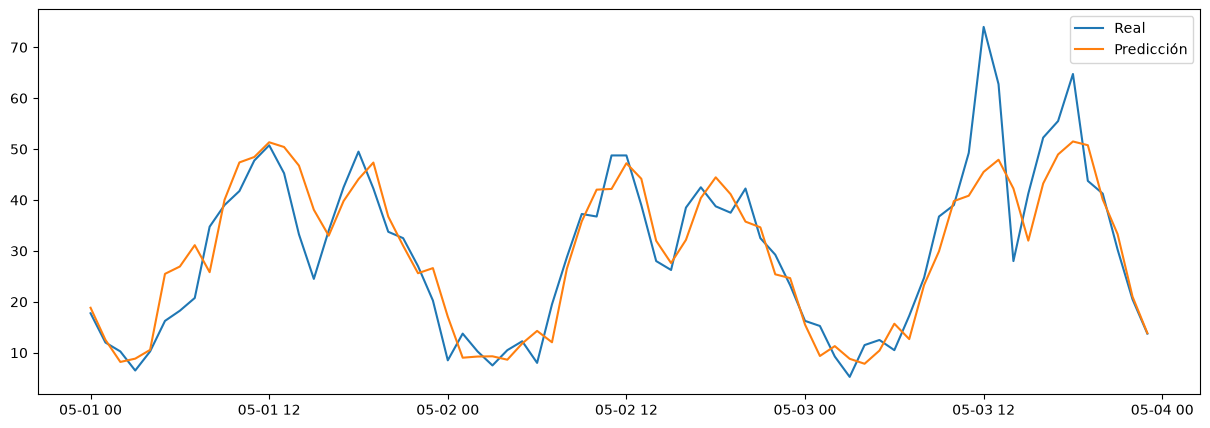

In [28]:
plt.figure(figsize=(15,5))

plt.plot(sensor_df["fecha_hora"], sensor_df["target"], label="Real")
plt.plot(sensor_df["fecha_hora"], pred_sensor, label="Predicción")

plt.legend()
plt.show()

En la visualización temporal de un sensor representativo, correspondiente a 72 horas consecutivas del conjunto de prueba, se observa que las predicciones reproducen fielmente la estructura diaria de la ocupación: los valles nocturnos, las subidas de la mañana y el doble pico característico de las horas punta. En los rangos de ocupación baja y media, la predicción se mantiene prácticamente superpuesta a los valores reales.

Se aprecian dos limitaciones características del modelo. Por un lado, una atenuación de los picos máximos, donde la predicción queda por debajo del valor real; por otro, un leve retraso en las transiciones más bruscas, en las que la predicción alcanza el cambio con aproximadamente una hora de desfase. Ambos comportamientos son coherentes con la naturaleza autorregresiva de las variables predictoras —el modelo se apoya fuertemente en el estado actual del tráfico— y con la menor representación de los valores extremos en el conjunto de entrenamiento, y coinciden con lo observado en el análisis de errores individuales y en la comparación de distribuciones.

In [31]:
# Importancia de variables
# LightGBM expone feature_importances_; HistGradientBoosting no,
# por lo que en ese caso se usa permutation_importance sobre una submuestra.
if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.DataFrame({
        "Variable": X_train_pd.columns,
        "Importancia": modelo_final.feature_importances_
    })
else:
    from sklearn.inspection import permutation_importance
    idx = X_test_pd.sample(50_000, random_state=42).index
    perm = permutation_importance(
        modelo_final,
        X_test_pd.loc[idx],
        y_test.to_numpy()[idx],
        n_repeats=3,
        random_state=42,
        n_jobs=-1
    )
    importancias = pd.DataFrame({
        "Variable": X_train_pd.columns,
        "Importancia": perm.importances_mean
    })

#importancias = pd.DataFrame({
#    "Variable": X_train_pd.columns,
#    "Importancia": modelo_final.booster_.feature_importance(importance_type="gain")
#})

importancias["Importancia"] = (
    importancias["Importancia"] / importancias["Importancia"].sum() * 100
)

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

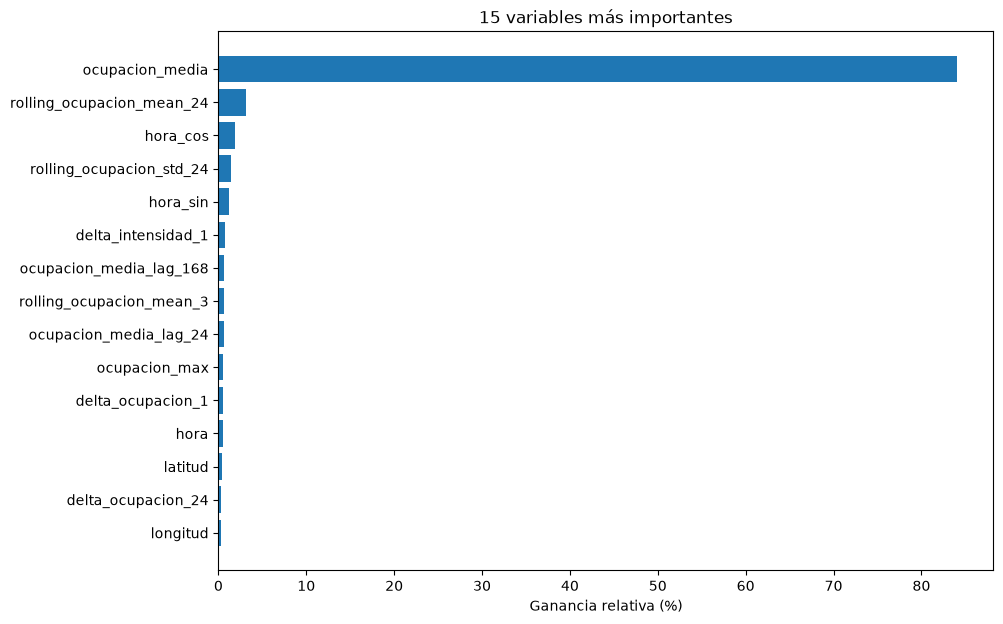

In [ ]:
plt.figure(figsize=(10,7))

plt.barh(
    importancias["Variable"][:15],
    importancias["Importancia"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Ganancia relativa (%)")
plt.title("15 variables más importantes")

plt.show()

El análisis de importancia por ganancia muestra una estructura claramente jerárquica: la ocupación actual (`ocupacion_media`) concentra la gran mayoría de la capacidad predictiva del modelo, lo que confirma la fuerte autocorrelación horaria del tráfico y explica por qué la persistencia constituye un baseline exigente.

El resto de las variables actúa como término de corrección sobre esa predicción base. Destacan el comportamiento reciente del sensor (`rolling_ocupacion_mean_24`, `rolling_ocupacion_std_24`), que aporta el contexto de las últimas 24 horas, y las variables cíclicas horarias (`hora_cos`, `hora_sin`), que permiten al modelo anticipar la fase del ciclo diario —si la ocupación está por entrar en hora punta o en valle—. Los lags diario y semanal y las variables de tendencia completan estos ajustes.

Esta estructura es consistente con los resultados globales: la reducción del 28,5% de MAE respecto a la persistencia corresponde precisamente a la contribución conjunta de estas variables de corrección, y las limitaciones observadas en la serie temporal del sensor (retraso en transiciones bruscas y atenuación de picos) derivan de la dependencia dominante del estado actual. Se empleó la importancia por ganancia en lugar del conteo de particiones, dado el sesgo de este último hacia variables continuas de alta cardinalidad como las coordenadas geográficas o el identificador de sensor.

In [ ]:
errores_df = pd.DataFrame({
    "Real": y_test.to_numpy(),
    "Predicción": pred_test
})

errores_df["Error absoluto"] = (
    errores_df["Real"] -
    errores_df["Predicción"]
).abs()

errores_df.sort_values(
    "Error absoluto",
    ascending=False
).head(20)

,Real,Predicción,Error absoluto
40975,0.00,105.733152,105.733152
29631,0.00,104.497223,104.497223
318382,100.00,2.905834,97.094166
776234,100.00,4.357463,95.642537
453455,92.00,0.562985,91.437015
454783,92.00,0.734295,91.265705
952060,100.00,8.801822,91.198178
458724,93.00,5.094821,87.905179
192545,1.25,89.109390,87.859390
491004,89.00,3.625263,85.374737


El análisis de errores individuales muestra que los mayores errores se concentran en situaciones extremas de ocupación, donde el modelo tiende a subestimar valores muy elevados y sobreestimar valores cercanos a cero. Esto indica que, aunque el modelo presenta un buen rendimiento global, las situaciones menos frecuentes y con cambios bruscos de tráfico siguen siendo más difíciles de predecir. Estos casos podrían mejorarse mediante un mayor ajuste de hiperparámetros, técnicas específicas para valores extremos o incorporando variables adicionales relacionadas con eventos excepcionales.

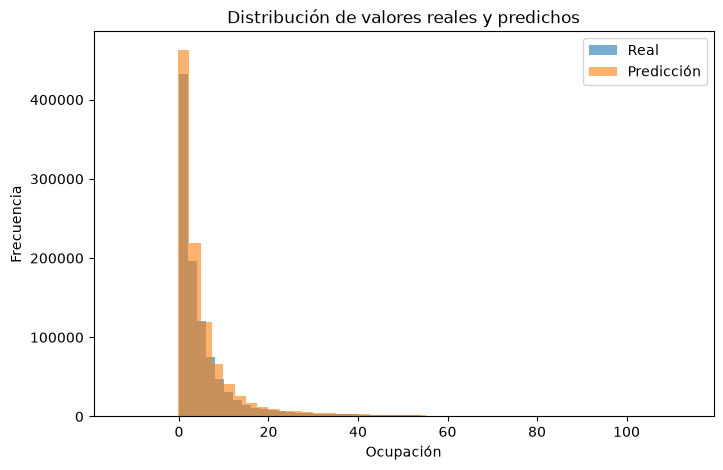

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test.to_numpy(),
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.hist(
    pred_test,
    bins=50,
    alpha=0.6,
    label="Predicción"
)

plt.xlabel("Ocupación")
plt.ylabel("Frecuencia")

plt.title("Distribución de valores reales y predichos")

plt.legend()

plt.show()

La distribución de valores reales y predichos muestra que el modelo reproduce correctamente los rangos de ocupación más frecuentes, donde se concentra la mayor parte de las observaciones. Sin embargo, se observa una menor presencia de predicciones en los valores extremos altos respecto a los valores reales, indicando cierta tendencia del modelo a suavizar los picos de ocupación. Este comportamiento es habitual en modelos de regresión cuando los eventos extremos tienen menor representación en los datos de entrenamiento.

### Paso 4: Almacenamiento del modelo

In [ ]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    modelo_final,
    MODEL_DIR / "trafico.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente
